# ESSOS Fieldlines And Particles

## What you will learn
How fieldline and particle diagnostics become validation gates for coil and reactor designs.

## Codes used
ESSOS in research mode; synthetic fieldline/orbit fallback by default.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
`06_fieldlines.png`, `06_particle_orbit.png`, and generated GIFs.

## What this teaches

The object is a dynamical diagnostic: fieldlines and particle-orbit cartoons as gates after geometry optimization.

## What this does not prove

It does not prove reactor-grade alpha confinement or a live ESSOS particle trace.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Learning frame

This notebook is a deliberately small project: define one metric, produce one plot, expose one failure mode, and identify where a real code would enter.

In [5]:
from sos2026.plotting import savefig, caption, fix_matplotlib_3d

## 2. Load or generate the teaching data

Cached mode uses small arrays so the conceptual workflow is always available.

In [6]:
t = np.linspace(0, 18*np.pi, 1400)
r = 1 + 0.18*np.cos(0.22*t)
fieldline = pd.DataFrame({"x": r*np.cos(t/4), "y": r*np.sin(t/4), "z": 0.16*np.sin(t)})
fieldline.head()

,x,y,z
0,1.180000,0.000000,0.000000
1,1.179933,0.011924,0.006466
2,1.179731,0.023846,0.012921
3,1.179394,0.035765,0.019354
4,1.178922,0.047679,0.025757


## 3. Make the primary plot

Every plot has a one-sentence caption because students should know how to read it without guessing.

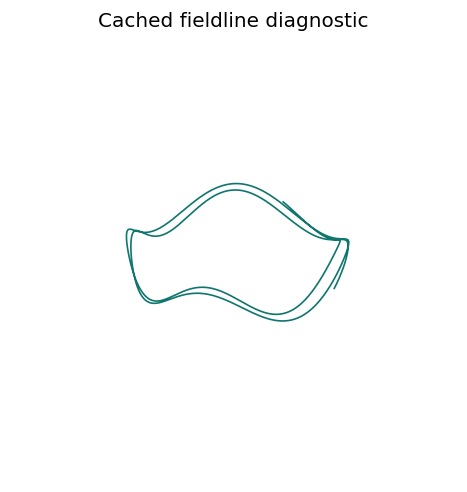

Caption: fieldline plots diagnose magnetic topology but do not prove particle confinement.


In [7]:
fig = plt.figure(figsize=(5.8, 4.2))
ax = fig.add_subplot(111, projection="3d")
ax.plot(fieldline.x, fieldline.y, fieldline.z, color="#0f766e", lw=1)
ax.set_axis_off()
ax.set_title("Cached fieldline diagnostic")
fix_matplotlib_3d(ax)
savefig(fig, "06_fieldlines.png")
plt.show()
print("Caption: fieldline plots diagnose magnetic topology but do not prove particle confinement.")

## 4. Probe the metric

A metric becomes useful for optimization only when we understand how it changes across design choices.

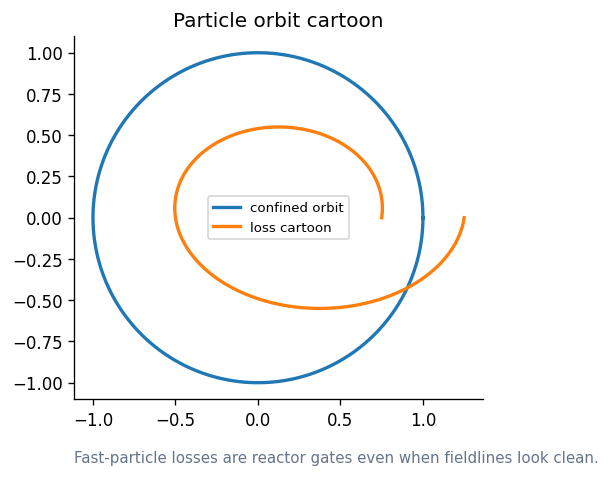

In [8]:
phi = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots(figsize=(5.6, 4.1))
ax.plot(np.cos(phi), np.sin(phi), lw=2, label="confined orbit")
ax.plot(0.75*np.cos(phi) + 0.25*phi/np.pi, 0.55*np.sin(phi), lw=2, label="loss cartoon")
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title("Particle orbit cartoon")
caption(ax, "Fast-particle losses are reactor gates even when fieldlines look clean.")
savefig(fig, "06_particle_orbit.png")
plt.show()

## 5. Interpret the design consequence

The table below translates the plot into an optimization decision.

In [9]:
checks = pd.DataFrame({
    "diagnostic": ["fieldline", "guiding-center orbit", "full orbit", "wall hit map"],
    "cost": ["low", "medium", "higher", "postprocess"],
    "design_use": ["topology", "fast-ion screen", "validation", "engineering risk"],
})
checks

,diagnostic,cost,design_use
0,fieldline,low,topology
1,guiding-center orbit,medium,fast-ion screen
2,full orbit,higher,validation
3,wall hit map,postprocess,engineering risk


## 6. Failure mode

The cached plot is useful only if we say what it does not prove.

In [10]:
failure_mode = pd.DataFrame({
    "cached_mode_proves": ["workflow shape", "plot grammar", "where the metric enters"],
    "cached_mode_does_not_prove": ["validated physics", "final design ranking", "runtime scalability"],
})
failure_mode

,cached_mode_proves,cached_mode_does_not_prove
0,workflow shape,validated physics
1,plot grammar,final design ranking
2,where the metric enters,runtime scalability


## 7. Research-mode hook

Run this cell only after timing the package on the lecture machine.

In [11]:
if RUN_MODE == "research":
    import essos
    print("ESSOS import OK; research path: run a tiny fieldline tracing example.")
else:
    print("Cached mode: research package path skipped intentionally.")

Cached mode: research package path skipped intentionally.


## 8. Mini project handoff

Use this notebook during the lecture as the computational project slide points to: change one parameter, regenerate one plot, and explain one design tradeoff.

In [12]:
project_steps = pd.DataFrame({
    "step": [1, 2, 3, 4],
    "action": ["identify metric", "change one input", "regenerate plot", "state failure mode"],
})
project_steps

,step,action
0,1,identify metric
1,2,change one input
2,3,regenerate plot
3,4,state failure mode


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

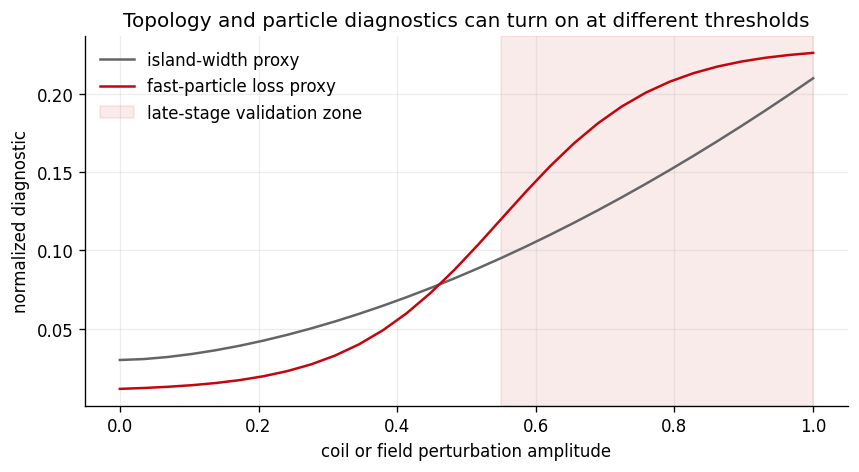

Caption: fieldline diagnostics screen topology, while fast-particle metrics decide whether a reactor claim is credible.


In [13]:
perturbation = np.linspace(0, 1, 30)
island_width = 0.03 + 0.18 * perturbation**1.7
fast_particle_loss = 0.01 + 0.22 / (1 + np.exp(-9 * (perturbation - 0.55)))
fig, ax = plt.subplots(figsize=(8.2, 4.0))
ax.plot(perturbation, island_width, color="#646569", label="island-width proxy")
ax.plot(perturbation, fast_particle_loss, color="#c5050c", label="fast-particle loss proxy")
ax.axvspan(0.55, 1.0, color="#c5050c", alpha=0.08, label="late-stage validation zone")
ax.set_xlabel("coil or field perturbation amplitude")
ax.set_ylabel("normalized diagnostic")
ax.set_title("Topology and particle diagnostics can turn on at different thresholds")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.show()
print("Caption: fieldline diagnostics screen topology, while fast-particle metrics decide whether a reactor claim is credible.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Change one scalar or one row in the cached data and regenerate the primary plot.

## Expected qualitative answer
The plot should move in a physically interpretable direction, but the cached result remains an educational proxy.

## Research extension
Replace the cached data source with the corresponding real package output after timing and API verification.